In [3]:
#import necessary libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from matplotlib.ticker import AutoMinorLocator

import xarray as xr
import scipy

from scipy import stats
from scipy.stats import pearsonr, linregress

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

import time
from datetime import datetime, date

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.dates as mdates


import shapefile
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
import os

import sys
import os.path
import subprocess
import math
import csv

from netCDF4 import Dataset

#import s3fs
import copy
import json, copy
from pandas import DataFrame
from osgeo import gdal, ogr, osr

import warnings
warnings.filterwarnings("ignore")

In [4]:
def epoch_to_decimal_year(epoch_str):
    dt = datetime.strptime(epoch_str, "%Y%m%d.%H%M")
    year = dt.year
    start_of_year = datetime(year, 1, 1)
    next_year = datetime(year+1, 1, 1)
    year_elapsed = (dt - start_of_year).total_seconds()
    year_length = (next_year - start_of_year).total_seconds()
    return year + year_elapsed / year_length

# Read and parse file for a geocenter solution (change filename for GEOC-GFZ, GEOC-JPL)
filename = "TN-13_GEOC_CSR_RL0602.txt"
records = []

with open(filename, "r") as f:
    for line in f:
        # Skip headers/comments
        if line.startswith("GRCOF2"):
            parts = line.split()
            degree = int(parts[1])
            order = int(parts[2])
            clm = float(parts[3])
            slm = float(parts[4])
            epoch_begin = parts[7]
            epoch_stop = parts[8]
            epoch_mid = epoch_to_decimal_year(epoch_begin)
            records.append([degree, order, clm, slm, epoch_mid])

# Create DataFrame
df = pd.DataFrame(records, columns=["degree", "order", "clm", "slm", "epoch"])
df

,degree,order,clm,slm,epoch
0,1,0,5.120437e-10,0.000000e+00,2002.257534
1,1,1,2.897447e-10,-6.826708e-11,2002.257534
2,1,0,4.542913e-10,0.000000e+00,2002.334247
3,1,1,1.584053e-10,-8.940349e-11,2002.334247
4,1,0,-6.684092e-12,0.000000e+00,2002.580822
...,...,...,...,...,...
459,1,1,-1.063265e-10,3.496893e-10,2024.084699
460,1,0,-6.429940e-10,0.000000e+00,2024.163934
461,1,1,-1.055608e-10,3.257235e-10,2024.163934
462,1,0,-7.267846e-10,0.000000e+00,2024.248634


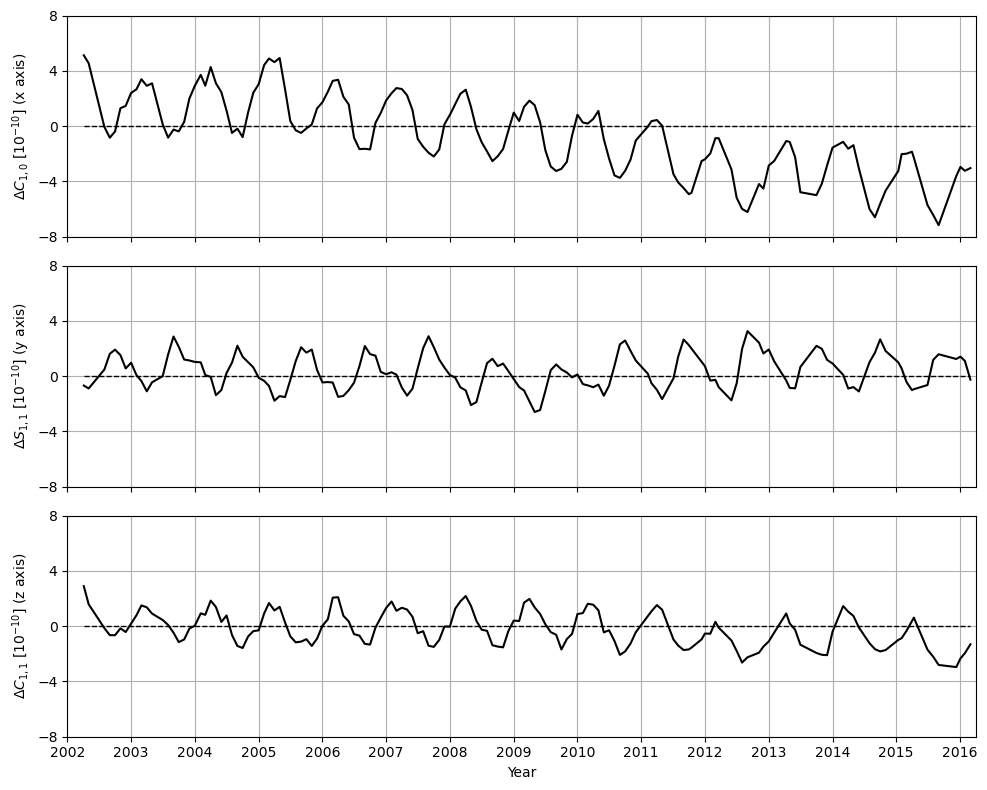

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates

def epoch_str_to_datetime(epoch_str):
    return datetime.strptime(epoch_str, "%Y%m%d.%H%M")

filename = "TN-13_GEOC_CSR_RL0602.txt"
records = []
with open(filename, "r") as f:
    for line in f:
        if line.startswith("GRCOF2"):
            parts = line.split()
            degree = int(parts[1])
            order = int(parts[2])
            clm = float(parts[3])
            slm = float(parts[4])
            epoch_begin_str = parts[7]
            epoch_begin_dt = epoch_str_to_datetime(epoch_begin_str)
            records.append([degree, order, clm, slm, epoch_begin_dt])

df = pd.DataFrame(records, columns=["degree", "order", "clm", "slm", "epoch_begin"])

start_date = datetime(2002, 1, 1)  # start from 2002-01 for axis
data_start = datetime(2002, 4, 1)  # actual data
end_date = datetime(2016, 3, 31)

c10 = df[(df["degree"] == 1) & (df["order"] == 0) & (df["epoch_begin"] >= data_start) & (df["epoch_begin"] <= end_date)]
c11 = df[(df["degree"] == 1) & (df["order"] == 1) & (df["epoch_begin"] >= data_start) & (df["epoch_begin"] <= end_date)]
s11 = df[(df["degree"] == 1) & (df["order"] == 1) & (df["epoch_begin"] >= data_start) & (df["epoch_begin"] <= end_date)]

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for ax, data, ylab in zip(
    axs,
    [(c10["epoch_begin"], c10["clm"]*1e10),
     (s11["epoch_begin"], s11["slm"]*1e10),
     (c11["epoch_begin"], c11["clm"]*1e10)],
    [r'$\Delta C_{1,0}$ $[10^{-10}]$ (x axis)',
     r'$\Delta S_{1,1}$ $[10^{-10}]$ (y axis)',
     r'$\Delta C_{1,1}$ $[10^{-10}]$ (z axis)']):
    
    ax.plot(*data, color='k', label="GEOC-CSR")
    ax.set_ylabel(ylab)
    ax.grid(True)
    # ax.legend(loc="upper right")
    ax.set_ylim(-8, 8)
    ax.set_yticks(np.arange(-8, 9, 4))
    ax.hlines(0, data[0].min(), data[0].max(), colors='k', linestyles='--', linewidth=1)


axs[-1].set_xlabel('Year')

# Set up major ticks/labels for years
axs[-1].xaxis.set_major_locator(mdates.YearLocator())
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Set limits to exactly 2002 to 2016-03
axs[-1].set_xlim([start_date, end_date])

fig.tight_layout()
plt.show()

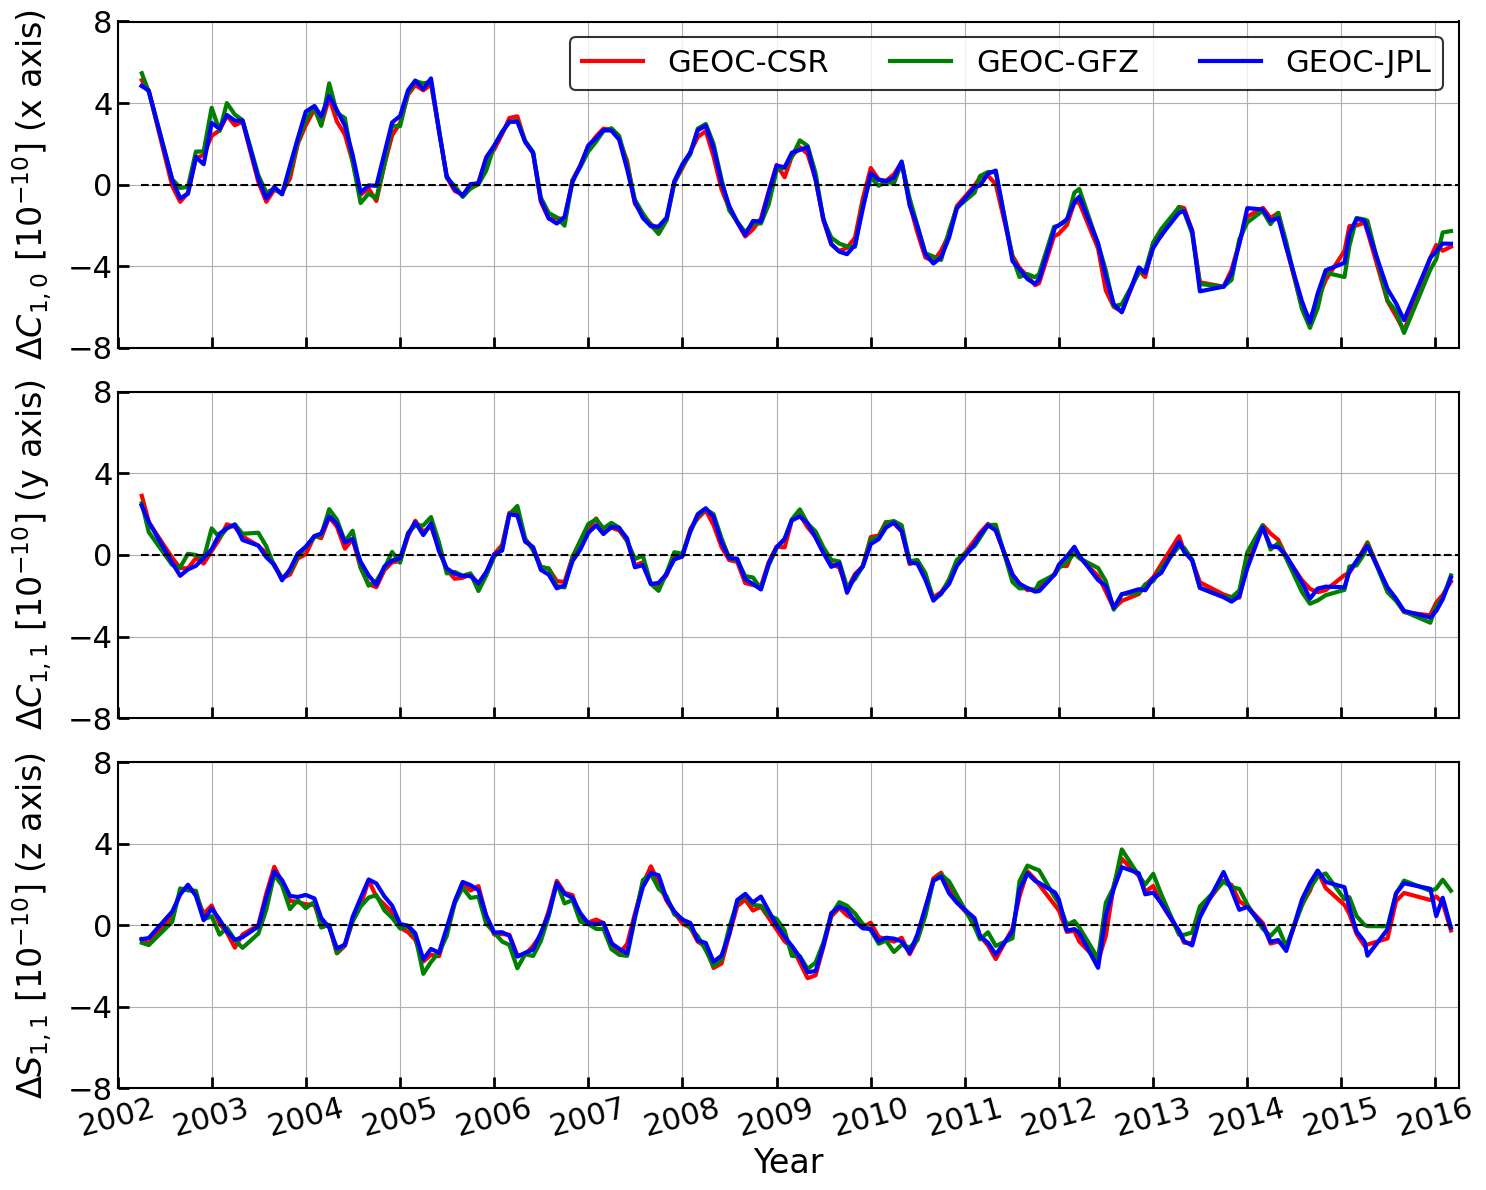

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates

def read_geocenter_file(filename):
    records = []
    with open(filename, "r") as f:
        for line in f:
            if line.startswith("GRCOF2"):
                parts = line.split()
                degree = int(parts[1])
                order = int(parts[2])
                clm = float(parts[3])
                slm = float(parts[4])
                epoch_begin_str = parts[7]
                epoch_begin_dt = datetime.strptime(epoch_begin_str, "%Y%m%d.%H%M")
                records.append([degree, order, clm, slm, epoch_begin_dt])
    return pd.DataFrame(records, columns=["degree", "order", "clm", "slm", "epoch_begin"])

# Read all files
df_csr = read_geocenter_file("TN-13_GEOC_CSR_RL0602.txt")
df_gfz = read_geocenter_file("TN-13_GEOC_GFZ_RL0601.txt")
df_jpl = read_geocenter_file("TN-13_GEOC_JPL_RL0601.txt")

start_date = datetime(2002, 4, 1)
end_date = datetime(2016, 3, 31)

def filter_degree1(df):
    df = df[(df["epoch_begin"] >= start_date) & (df["epoch_begin"] <= end_date)]
    c10 = df[(df["degree"] == 1) & (df["order"] == 0)]
    c11 = df[(df["degree"] == 1) & (df["order"] == 1)]
    s11 = df[(df["degree"] == 1) & (df["order"] == 1)]
    return c10, c11, s11

c10_csr, c11_csr, s11_csr = filter_degree1(df_csr)
c10_gfz, c11_gfz, s11_gfz = filter_degree1(df_gfz)
c10_jpl, c11_jpl, s11_jpl = filter_degree1(df_jpl)

fig, axs = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for ax, ylab, c10_dfs, c11_dfs, s11_dfs, in zip(
    axs,
    [r'$\Delta C_{1,0}$ $[10^{-10}]$ (x axis)',
     r'$\Delta C_{1,1}$ $[10^{-10}]$ (y axis)',
     r'$\Delta S_{1,1}$ $[10^{-10}]$ (z axis)'],
    
    [c10_csr, c10_gfz, c10_jpl],
    [c11_csr, c11_gfz, c11_jpl],
    [s11_csr, s11_gfz, s11_jpl]
    
):
    # Plot CSR
    if ax == axs[0]:
        ax.plot(c10_csr["epoch_begin"], c10_csr["clm"]*1e10, label="GEOC-CSR", color='r', linewidth=3)
        ax.plot(c10_gfz["epoch_begin"], c10_gfz["clm"]*1e10, label="GEOC-GFZ", color='g', linewidth=3)
        ax.plot(c10_jpl["epoch_begin"], c10_jpl["clm"]*1e10, label="GEOC-JPL", color='b', linewidth=3)
    elif ax == axs[1]:
        ax.plot(c11_csr["epoch_begin"], c11_csr["clm"]*1e10, label="GEOC-CSR", color='r', linewidth=3)
        ax.plot(c11_gfz["epoch_begin"], c11_gfz["clm"]*1e10, label="GEOC-GFZ", color='g', linewidth=3)
        ax.plot(c11_jpl["epoch_begin"], c11_jpl["clm"]*1e10, label="GEOC-JPL", color='b', linewidth=3)
    elif ax == axs[2]:
        ax.plot(s11_csr["epoch_begin"], s11_csr["slm"]*1e10, label="GEOC-CSR", color='r', linewidth=3)
        ax.plot(s11_gfz["epoch_begin"], s11_gfz["slm"]*1e10, label="GEOC-GFZ", color='g', linewidth=3)
        ax.plot(s11_jpl["epoch_begin"], s11_jpl["slm"]*1e10, label="GEOC-JPL", color='b', linewidth=3)
    
        
    ax.set_ylabel(ylab)
    ax.grid(True)
    ax.set_ylim(-8, 8)
    ax.set_yticks(np.arange(-8, 9, 4))
    

    ax.tick_params(axis='y', labelsize=22, width=2, length=8, direction='in', top=True, bottom=True)
    ax.tick_params(axis='x', labelsize=22, width=2, length=8, direction='in', left=True, right=True)
    ax.hlines(0, start_date, end_date, colors='k', linestyles='--', linewidth=1.5)

    ax.set_ylabel(
        ylab,
        fontsize=24,
        fontweight='normal',
        color='black',
        labelpad=10  # spacing from axis
    )


    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')
        
    leg = axs[0].legend(loc="upper right", fontsize=22, ncol=3)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.5)
  

axs[-1].set_xlabel('Year', fontsize=24, fontweight='normal', color='black')
axs[-1].tick_params(axis='x', labelrotation=15)  # Rotate x-axis tick labels by 45 degrees

axs[-1].xaxis.set_major_locator(mdates.YearLocator())
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs[-1].set_xlim([datetime(2002, 1, 1), end_date])



fig.tight_layout()
plt.savefig(r'Geocenter_correction_GRACE_3DC_Timeseries_new1.png', dpi=300, bbox_inches='tight')
plt.show()